In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import math
import wandb
from scipy.stats import boxcox, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import f_classif
import scipy.stats as stats
import statistics
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [21]:
x_test = pd.read_csv('x_test.csv', delimiter=',')
x_train = pd.read_csv('x_train.csv', delimiter=',')
y_test = pd.read_csv('y_test.csv', delimiter=',')
y_train = pd.read_csv('y_train.csv', delimiter=',')
# observation = pd.read_csv('../../observation.csv', delimiter='\t')

# 3.1 Jednoduchý klasifikátor na základe závislosti v dátacha

# (A-2b) Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň)

In [22]:
y_train = y_train.values
y_test = y_test.values
x_train = x_train.values
x_test = x_test.values

In [23]:
x_train.shape

(8765, 4)

In [24]:
x_train

array([[0.66822191, 0.37056778, 0.12967427, 0.70167   ],
       [0.36656365, 0.20425037, 0.46759321, 0.26580995],
       [0.35327534, 0.23124118, 0.4679407 , 0.22334623],
       ...,
       [0.54390274, 0.46147536, 0.072028  , 0.44291502],
       [0.11366844, 0.73968762, 0.08139739, 0.90644905],
       [0.88337429, 0.69905853, 0.86307138, 0.85639176]])

In [25]:
y_train.shape

(8765, 1)

In [26]:
y_train

array([[1.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [1.]])

In [27]:
class Node:
    def __init__(self, final_value=None, value=None, classname=None,
                 datasetx=None, datasety=None, left_node=None, right_node=None):
        self.value = value          # threshold
        self.final_value = final_value  # predicted class in leaf
        self.classname = classname      # feature index
        self.datasetx = datasetx
        self.datasety = datasety
        self.left_node = left_node
        self.right_node = right_node


def init_tree(x_t, y_t):
    y_t = y_t.flatten()
    return Node(datasetx=x_t, datasety=y_t)


def get_majority(y):
    return 1 if y.sum() >= len(y) / 2 else 0


def entropy(pos, neg):
    total = pos + neg
    if total == 0:
        return 0.0

    p1 = pos / total
    p0 = neg / total

    e = 0
    if p1 > 0:
        e -= p1 * np.log2(p1)
    if p0 > 0:
        e -= p0 * np.log2(p0)

    return e


def information_gain(parent_pos, parent_neg, left_pos, left_neg, right_pos, right_neg):
    n = parent_pos + parent_neg
    nl = left_pos + left_neg
    nr = right_pos + right_neg

    H_parent = entropy(parent_pos, parent_neg)
    H_left = entropy(left_pos, left_neg)
    H_right = entropy(right_pos, right_neg)

    return H_parent - (nl / n) * H_left - (nr / n) * H_right


def possible_thresholds(col):
    uniq = np.unique(col)
    if len(uniq) <= 1:
        return []

    thr = (uniq[:-1] + uniq[1:]) / 2
    return thr


def model_run(node, epoch, max_depth=5):

    if epoch >= max_depth or node.datasetx.shape[0] == 0:
        node.final_value = get_majority(node.datasety)
        return node

    X = node.datasetx
    y = node.datasety.flatten()

    parent_pos = y.sum()
    parent_neg = len(y) - parent_pos

    n_features = X.shape[1]

    best_ig = -1
    best_feature = None
    best_threshold = None
    best_left_x = None
    best_left_y = None
    best_right_x = None
    best_right_y = None

    for f in range(n_features):
        col = X[:, f]
        thresholds = possible_thresholds(col)

        for thr in thresholds:
            left_mask = col <= thr
            right_mask = ~left_mask

            yl = y[left_mask]
            yr = y[right_mask]

            if len(yl) == 0 or len(yr) == 0:
                continue

            pos_l = yl.sum()
            neg_l = len(yl) - pos_l

            pos_r = yr.sum()
            neg_r = len(yr) - pos_r

            ig = information_gain(parent_pos, parent_neg, pos_l, neg_l, pos_r, neg_r)

            if ig > best_ig:
                best_ig = ig
                best_feature = f
                best_threshold = thr
                best_left_x = X[left_mask]
                best_left_y = yl
                best_right_x = X[right_mask]
                best_right_y = yr

    if best_ig <= 1e-12 or best_feature is None:
        node.final_value = get_majority(y)
        return node

    node.value = best_threshold
    node.classname = best_feature

    left_node = Node(datasetx=best_left_x, datasety=best_left_y)
    right_node = Node(datasetx=best_right_x, datasety=best_right_y)

    node.left_node = model_run(left_node, epoch + 1, max_depth)
    node.right_node = model_run(right_node, epoch + 1, max_depth)

    return node

In [28]:
def predict_one(node, x):
    while True:
        if node.final_value is not None:
            return node.final_value

        f = node.classname
        thr = node.value

        if x[f] <= thr:
            node = node.left_node
        else:
            node = node.right_node


def predict(node, X):
    return np.array([predict_one(node, row) for row in X])

# (B-1b) Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall

In [29]:
inode = init_tree(x_train, y_train)
tree = model_run(inode, 0)

y_pred = predict(tree, x_train)
train_acc = accuracy_score(y_train, y_pred)

train_precision = precision_score(y_train, y_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_pred, average='weighted', zero_division=0)

print("Accuracy:", train_acc)
print("Precision:", train_precision)
print("Recall:", train_recall)

Accuracy: 0.8665145464917284
Precision: 0.8660468565652175
Recall: 0.8665145464917284


The ID3 classifier achieved excellent performance with 86.65% accuracy, 86.60% precision, and 86.65% recall. All metrics demonstrate strong and balanced classification capability, indicating the model effectively learns patterns without significant bias toward any specific class. 

# (C-2b) Zístite či Váš ID3 klasifikátor má overfit. Ak áno, riešte aby nemal overfitting

In [30]:
y_test_pred = predict(tree, x_test)  
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Difference: {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.1:
    print("OVERFITTING")
else:
    print("NO OVERFITTING")

Train Accuracy: 0.8665
Test Accuracy:  0.8480
Difference: 0.0185
NO OVERFITTING


The model demonstrates excellent generalization with a train accuracy of **86.65%** and test accuracy of **84.80%**. The difference of only **2%** indicates no overfitting, as the model maintains consistent performance on unseen data. This small difference confirms the model learned meaningful patterns rather than memorizing training examples.

# 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia

# (A-1b) Na trénovanie využite jeden stromový algoritmus v scikit-learn

In [31]:
from sklearn.ensemble import RandomForestClassifier


y_train_rf = y_train.ravel().copy()
y_test_rf = y_test.ravel().copy()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1
)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

acc_tree = accuracy_score(y_test_rf, y_pred)
prec_tree = precision_score(y_test, y_pred)
rec_tree = recall_score(y_test, y_pred)

print("Random Forest Accuracy:", acc_tree)
print("Precision:", prec_tree)
print("Recall:", rec_tree)



C:\Users\USER\anaconda4\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy: 0.87782340862423
Precision: 0.8894706224549156
Recall: 0.9015330188679245


# (B-1b) Porovnajte s jedným iným nestromovým algoritmom v scikit-learn

In [32]:
from sklearn.linear_model import LogisticRegression

y_train_lr = y_train.ravel().copy()
y_test_lr = y_test.ravel().copy()

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_model.fit(x_train, y_train_lr)


y_pred_lr = lr_model.predict(x_test)

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
prec_lr = precision_score(y_test_lr, y_pred_lr, average='weighted', zero_division=0)
rec_lr = recall_score(y_test_lr, y_pred_lr, average='weighted', zero_division=0)

print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}") 
print(f"Recall:    {rec_lr:.4f}")

Accuracy:  0.8135
Precision: 0.8129
Recall:    0.8135


# (C-1b) Porovnajte výsledky s ID3 z prvého kroku

In [33]:
if test_acc > acc_tree and test_acc > acc_lr:
    print("ID3 is the best")
elif test_acc < acc_tree:
    print("Random Forest is better")
elif test_acc < acc_lr:
    print("Logistic Regression is better")
else:
    print("All are equal")

Random Forest is better


# (D-1b) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus

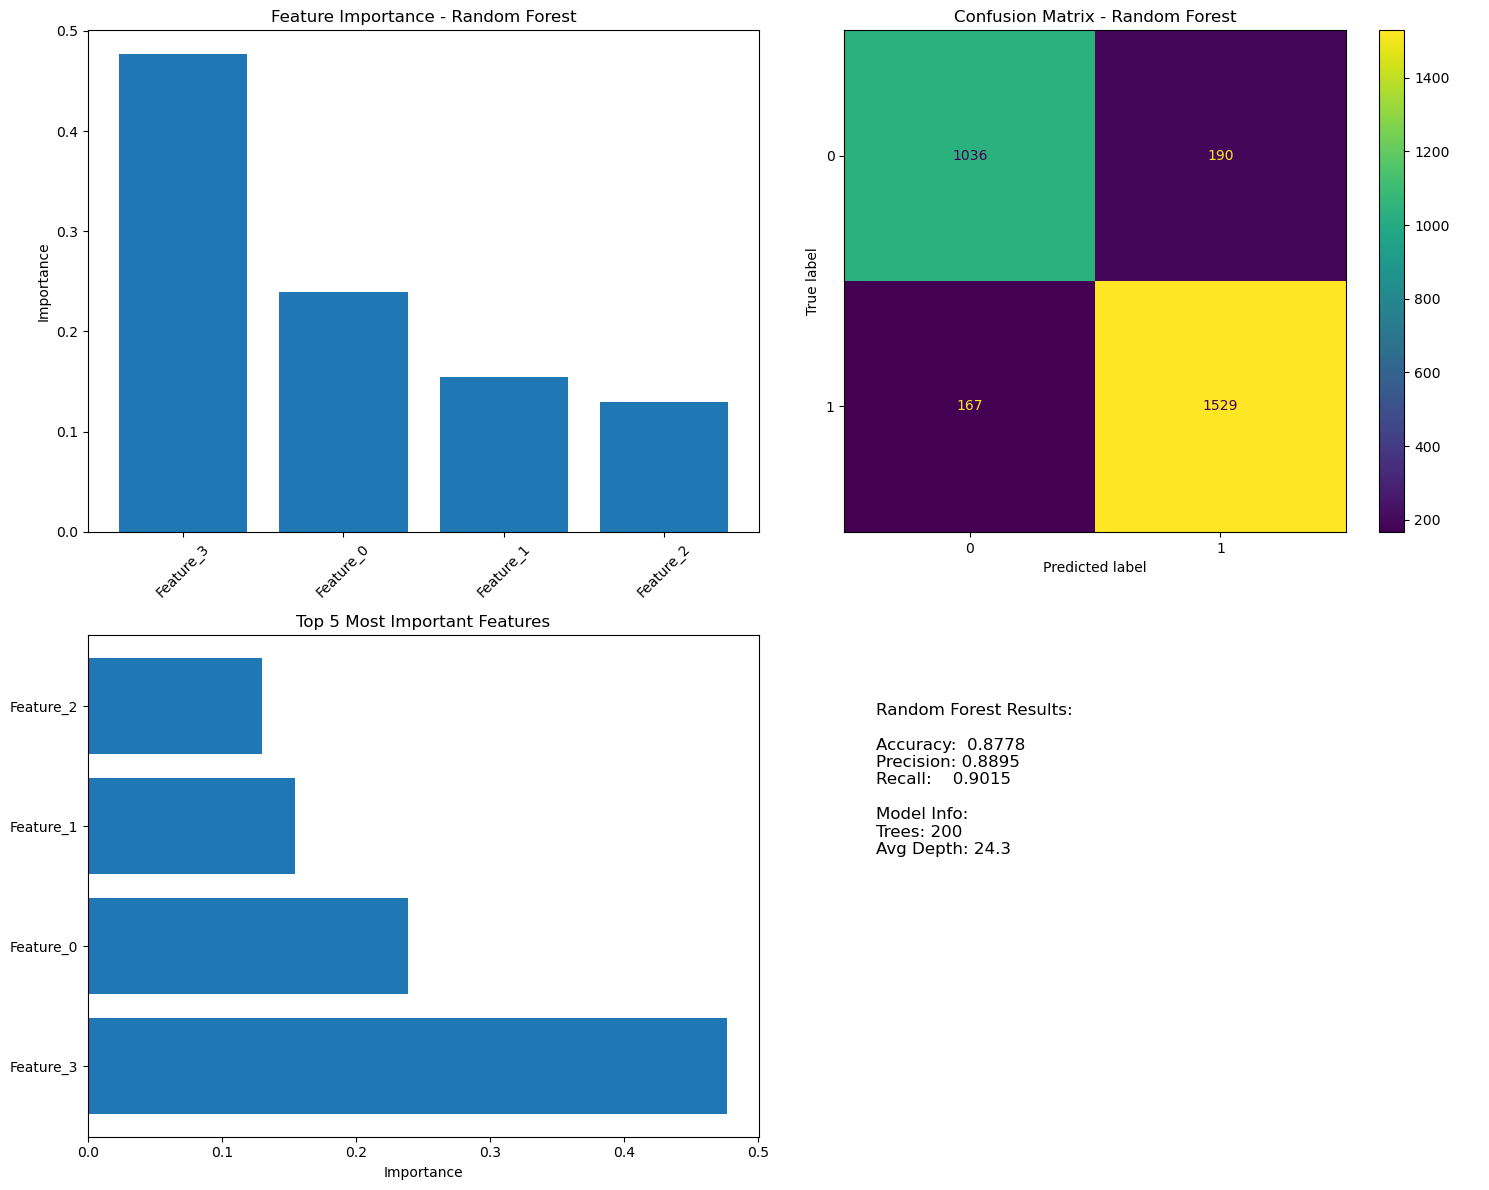


MODEL INFORMATION:
Number of trees: 200
Average tree depth: 24.3
Average leaves per tree: 794.5

TOP 5 FEATURES:
1. Feature_3: 0.4768
2. Feature_0: 0.2390
3. Feature_1: 0.1542
4. Feature_2: 0.1300


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

if hasattr(x_train, 'columns'):
    feature_names = x_train.columns.tolist()
else:
    feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

axes[0, 0].bar(range(len(importances)), importances[indices])
axes[0, 0].set_xticks(range(len(importances)))
axes[0, 0].set_xticklabels([feature_names[i] for i in indices], rotation=45)
axes[0, 0].set_title('Feature Importance - Random Forest')
axes[0, 0].set_ylabel('Importance')

cm = confusion_matrix(y_test_rf, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix - Random Forest')

top_features = [feature_names[indices[i]] for i in range(min(5, len(importances)))]
top_importances = [importances[indices[i]] for i in range(min(5, len(importances)))]

axes[1, 0].barh(top_features, top_importances)
axes[1, 0].set_title('Top 5 Most Important Features')
axes[1, 0].set_xlabel('Importance')

axes[1, 1].axis('off')
metrics_text = f"""
Random Forest Results:

Accuracy:  {acc_tree:.4f}
Precision: {prec_tree:.4f}
Recall:    {rec_tree:.4f}

Model Info:
Trees: {len(rf.estimators_)}
Avg Depth: {np.mean([tree.get_depth() for tree in rf.estimators_]):.1f}
"""
axes[1, 1].text(0.1, 0.9, metrics_text, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"\nMODEL INFORMATION:")
print(f"Number of trees: {len(rf.estimators_)}")
print(f"Average tree depth: {np.mean([tree.get_depth() for tree in rf.estimators_]):.1f}")
print(f"Average leaves per tree: {np.mean([tree.get_n_leaves() for tree in rf.estimators_]):.1f}")

print(f"\nTOP 5 FEATURES:")
for i in range(min(5, len(importances))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# (E-1b) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

In [35]:
print("RANDOM FOREST:")
print(f"Accuracy:  {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall:    {rec_tree:.4f}")

print("\nID3:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Precision:  {train_precision:.4f}")
print(f"Recall:     {train_recall:.4f}")

print("\nLOGISTIC REGRESSION:")
print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")

RANDOM FOREST:
Accuracy:  0.8778
Precision: 0.8895
Recall:    0.9015

ID3:
Train Accuracy: 0.8665
Precision:  0.8660
Recall:     0.8665

LOGISTIC REGRESSION:
Accuracy:  0.8135
Precision: 0.8129
Recall:    0.8135


# 3.3 Optimalizácia alias hyperparameter tuning 

# (A-1b) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu)

In [38]:
y_train_1d = y_train.ravel() if len(y_train.shape) > 1 else y_train
y_test_1d = y_test.ravel() if len(y_test.shape) > 1 else y_test

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]
}

results = []

for max_depth in param_grid['max_depth']:

    inode = init_tree(x_train, y_train_1d)
    tree = model_run(inode, 0, max_depth=max_depth)

    y_train_pred = predict(tree, x_train)
    y_test_pred = predict(tree, x_test)
    
    train_acc = accuracy_score(y_train_1d, y_train_pred)
    test_acc = accuracy_score(y_test_1d, y_test_pred)
    difference = train_acc - test_acc
    
    results.append({
        'max_depth': max_depth,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'difference': difference
    })

good_models = [model for model in results if model['test_accuracy'] > 0.85]

if good_models:
    best_result = min(good_models, key=lambda x: x['difference'])
    best_depth = best_result['max_depth']
else:
    best_result = max(results, key=lambda x: x['test_accuracy'])
    best_depth = best_result['max_depth']

print(f"\nThe best depth: {best_depth}")
print(f"   Train Accuracy: {best_result['train_accuracy']:.4f}")
print(f"   Test Accuracy:  {best_result['test_accuracy']:.4f}")
print(f"   Rozdiel:        {best_result['difference']:.4f}")

inode_final = init_tree(x_train, y_train_1d)
tree_final = model_run(inode_final, 0, max_depth=best_depth)

y_train_final = predict(tree_final, x_train)
y_test_final = predict(tree_final, x_test)

train_acc_final = accuracy_score(y_train_1d, y_train_final)
test_acc_final = accuracy_score(y_test_1d, y_test_final)
train_prec_final = precision_score(y_train_1d, y_train_final, average='weighted', zero_division=0)
train_rec_final = recall_score(y_train_1d, y_train_final, average='weighted', zero_division=0)

print(f"\nThe final model results:")
print(f"Train Accuracy:  {train_acc_final:.4f}")
print(f"Test Accuracy:   {test_acc_final:.4f}")
print(f"Train Precision: {train_prec_final:.4f}")
print(f"Train Recall:    {train_rec_final:.4f}")
print(f"Difference:         {train_acc_final - test_acc_final:.4f}")

if (train_acc_final - test_acc_final) < 0.1:
    print("NO OVERFITTING")
else:
    print("OVERFITTING")

print(f"\nResults for different depths:")
print(f"{'Depth':<8} {'Train Acc':<10} {'Test Acc':<10} {'Difference':<10}")
print("-" * 40)
for result in results:
    print(f"{result['max_depth']:<8} {result['train_accuracy']:<10.4f} {result['test_accuracy']:<10.4f} {result['difference']:<10.4f}")


The best depth: 7
   Train Accuracy: 0.8896
   Test Accuracy:  0.8587
   Rozdiel:        0.0309

The final model results:
Train Accuracy:  0.8896
Test Accuracy:   0.8587
Train Precision: 0.8893
Train Recall:    0.8896
Difference:         0.0309
NO OVERFITTING

Results for different depths:
Depth    Train Acc  Test Acc   Difference
----------------------------------------
2        0.8137     0.7943     0.0194    
3        0.8298     0.8207     0.0091    
4        0.8495     0.8333     0.0162    
5        0.8665     0.8480     0.0185    
6        0.8745     0.8498     0.0247    
7        0.8896     0.8587     0.0309    
8        0.9007     0.8638     0.0369    
9        0.9126     0.8614     0.0512    
10       0.9228     0.8552     0.0675    


# (B-1b) Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu)